## Diagramme de Bode du dernier circuit (intégrateur)

Montage de l'annexe 4.4 avec: $R10=100\,k\Omega$, $R9=10\,k\Omega$, $R11=10\,k\Omega$, $C=1\,\mu F$.


f_c    = 1.592 Hz  (pôle, gain -3 dB par rapport au plateau BF)
f_0dB  = 15.915 Hz  (croisement 0 dB)
Fréquence utilisée      : 35.0 Hz
Gain à 35 Hz            : -6.85 dB
Gain à 35 Hz (linéaire) : 0.4543
Phase à très basse fréq : -183.6°  (attendu ≈ -180°)
Phase à très haute fréq : -270.0°  (attendu ≈ -270°)
Phase à 35 Hz           : -267.4°


FileNotFoundError: [Errno 2] No such file or directory: 'Mécatro labo1/images/bode_dernier_circuit.png'

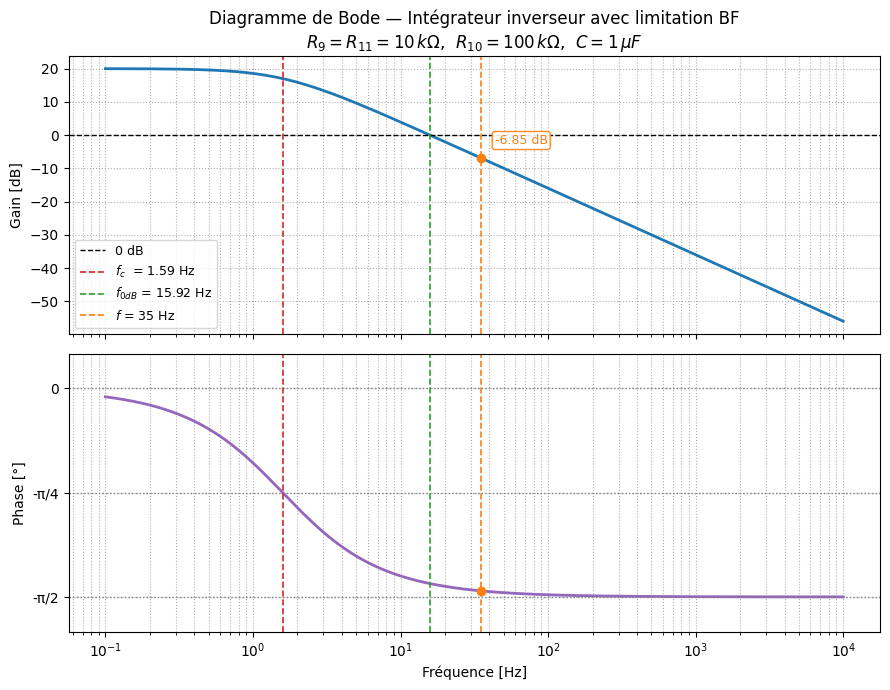

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres du montage intégrateur (annexe 4.4)
# Montage inverseur : H(jw) = -(R10/R9) / (1 + jw*R10*C)
R10 = 100e3   # 100 kΩ
R9  = 10e3    # 10 kΩ
R11 = 10e3    # 10 kΩ (compensation courant de biais)
C   = 1e-6    # 1 µF

# Fréquences
f = np.logspace(-1, 4, 2000)   # 0.1 Hz à 10 kHz
w = 2 * np.pi * f
s = 1j * w

# Fonction de transfert complète (signe − inclus)
H = -(R10 / R9) / (1 + s * R10 * C)

mag_db    = 20 * np.log10(np.abs(H))

# np.angle renvoie dans (-180°, +180°].
# Pour un amplificateur inverseur, la phase réelle est dans (-270°, -180°).
# Correction : on soustrait 360° pour passer de (90°..180°) → (-270°..-180°).
phase_deg = np.angle(H, deg=True) - 360   # ∈ (-270°, -180°)

# Fréquences caractéristiques
fc    = 1 / (2 * np.pi * R10 * C)         # pôle : 1.59 Hz
f0dB  = 1 / (2 * np.pi * R9  * C)         # gain = 0 dB : 15.9 Hz
f_ref = 35.0                              # fréquence utilisée pour le calcul final

H_ref        = -(R10 / R9) / (1 + 1j * 2 * np.pi * f_ref * R10 * C)
gain_ref     = np.abs(H_ref)
gain_ref_db  = 20 * np.log10(gain_ref)
phase_ref_deg = np.angle(H_ref, deg=True) - 360

print(f"f_c    = {fc:.3f} Hz  (pôle, gain -3 dB par rapport au plateau BF)")
print(f"f_0dB  = {f0dB:.3f} Hz  (croisement 0 dB)")
print(f"Fréquence utilisée      : {f_ref:.1f} Hz")
print(f"Gain à 35 Hz            : {gain_ref_db:.2f} dB")
print(f"Gain à 35 Hz (linéaire) : {gain_ref:.4f}")
print(f"Phase à très basse fréq : {phase_deg[0]:.1f}°  (attendu ≈ -180°)")
print(f"Phase à très haute fréq : {phase_deg[-1]:.1f}°  (attendu ≈ -270°)")
print(f"Phase à 35 Hz           : {phase_ref_deg:.1f}°")

# --- Tracé ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

# Gain
ax1.semilogx(f, mag_db, lw=2, color='tab:blue')
ax1.axhline(0, color='k', linestyle='--', lw=1, label='0 dB')
ax1.axvline(fc,   color='tab:red',   linestyle='--', lw=1.2, label=f'$f_c$  = {fc:.2f} Hz')
ax1.axvline(f0dB, color='tab:green', linestyle='--', lw=1.2, label=f'$f_{{0dB}}$ = {f0dB:.2f} Hz')
ax1.axvline(f_ref, color='tab:orange', linestyle='--', lw=1.2, label=f'$f$ = {f_ref:.0f} Hz')
ax1.plot(f_ref, gain_ref_db, 'o', color='tab:orange')
ax1.annotate(f'{gain_ref_db:.2f} dB',
             xy=(f_ref, gain_ref_db),
             xytext=(10, 10),
             textcoords='offset points',
             color='tab:orange',
             fontsize=9,
             bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='tab:orange', alpha=0.9))
ax1.set_ylabel('Gain [dB]')
ax1.legend(fontsize=9)
ax1.grid(True, which='both', ls=':')
ax1.set_title('Diagramme de Bode — Intégrateur inverseur avec limitation BF\n'
              r'$R_9=R_{11}=10\,k\Omega$,  $R_{10}=100\,k\Omega$,  $C=1\,\mu F$')

# Phase
ax2.semilogx(f, phase_deg, lw=2, color='tab:purple')
ax2.axhline(-180, color='gray', ls=':', lw=1)
ax2.axhline(-225, color='gray', ls=':', lw=1)
ax2.axhline(-270, color='gray', ls=':', lw=1)
ax2.axvline(fc,   color='tab:red',   linestyle='--', lw=1.2)
ax2.axvline(f0dB, color='tab:green', linestyle='--', lw=1.2)
ax2.axvline(f_ref, color='tab:orange', linestyle='--', lw=1.2)
ax2.plot(f_ref, phase_ref_deg, 'o', color='tab:orange')

ax2.set_yticks([-270, -225, -180])
ax2.set_yticklabels(['-π/2', '-π/4', '0'])
ax2.set_ylim(-285, -165)
ax2.set_ylabel('Phase [°]')
ax2.set_xlabel('Fréquence [Hz]')
ax2.grid(True, which='both', ls=':')

fig.tight_layout()
fig.savefig('bode_dernier_circuit.png', dpi=180)
import shutil
shutil.copy('bode_dernier_circuit.png',
            'Mécatro labo1/images/bode_dernier_circuit.png')
plt.show()
